In [12]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df=pd.read_csv('best_selling_video_games.csv')

In [4]:
df.head()

,Rank,Title,Platform(s),Developer(s),Publisher(s),Ref.,Releaseyear,Sales(millions),Series,Table_Number
0,1,Minecraft,Multi-platform,Mojang Studios,Mojang Studios,NaN,2011[b],350,Minecraft,1
1,2,Grand Theft Auto V,Multi-platform,Rockstar North,Rockstar Games,NaN,2013,225,Grand Theft Auto,1
2,3,Wii Sports[a],Wii,Nintendo EAD,Nintendo,NaN,2006,82.9,Wii,1
3,4,Red Dead Redemption 2,Multi-platform,Rockstar Games,Rockstar Games,NaN,2018,82,Red Dead,1
4,5,Mario Kart 8/Deluxe,Wii U/Switch,Nintendo EAD/Nintendo EPD(Deluxe),Nintendo,[c],2014,79.05,Mario Kart,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Rank             50 non-null     object
 1   Title            50 non-null     object
 2   Platform(s)      50 non-null     object
 3   Developer(s)     50 non-null     object
 4   Publisher(s)     42 non-null     object
 5   Ref.             10 non-null     object
 6   Releaseyear      50 non-null     object
 7   Sales(millions)  49 non-null     object
 8   Series           45 non-null     object
 9   Table_Number     50 non-null     int64 
dtypes: int64(1), object(9)
memory usage: 4.0+ KB


In [6]:
df.describe()

,Table_Number
count,50.0
mean,1.0
std,0.0
min,1.0
25%,1.0
50%,1.0
75%,1.0
max,1.0


In [7]:
df.isnull().sum()

Rank                0
Title               0
Platform(s)         0
Developer(s)        0
Publisher(s)        8
Ref.               40
Releaseyear         0
Sales(millions)     1
Series              5
Table_Number        0
dtype: int64

In [8]:
df["Releaseyear"] = df["Releaseyear"].str.extract(r'(\d{4})')
df["Releaseyear"] = pd.to_numeric(df["Releaseyear"],errors='coerce')


In [9]:
df["Rank"] = pd.to_numeric(df["Rank"],errors='coerce')
df["Sales(millions)"] = pd.to_numeric(df["Sales(millions)"],errors='coerce')


In [10]:
df = df.drop(columns=["Ref."], errors="ignore")

In [11]:
df["Publisher(s)"] = df["Publisher(s)"].fillna("Unknown")
df["Series"] = df["Series"].fillna("Standalone")

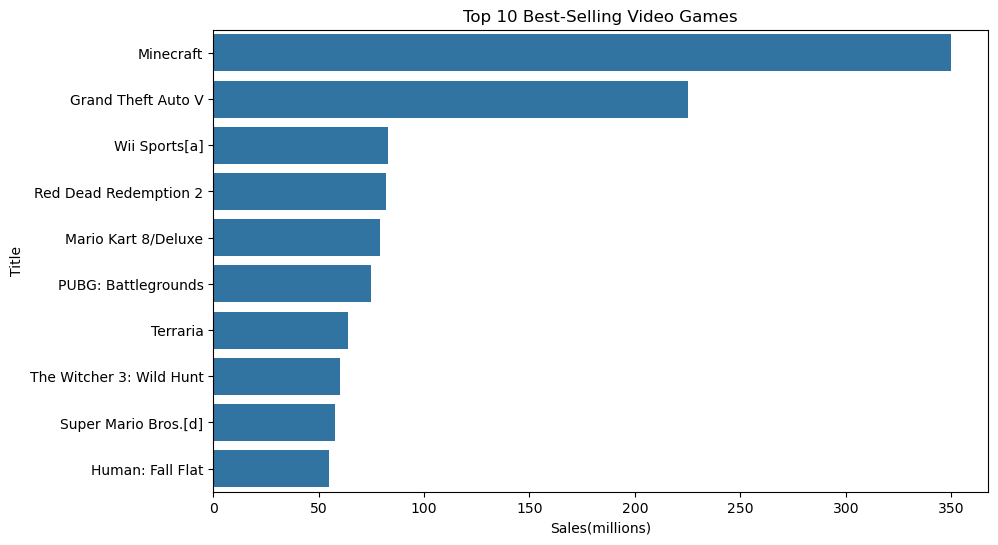

In [13]:
top10 = df.sort_values("Sales(millions)",ascending=False).head(10)
plt.figure(figsize=(10,6))
sns.barplot(data=top10,x="Sales(millions)",y="Title")
plt.title("Top 10 Best-Selling Video Games")
plt.show()

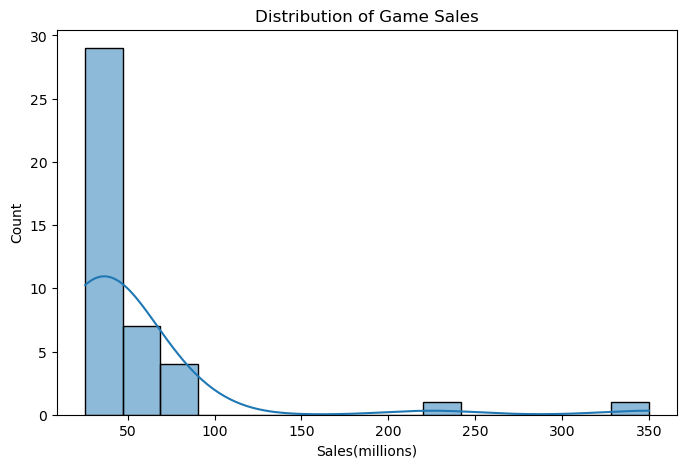

In [14]:

plt.figure(figsize=(8,5))
sns.histplot(df["Sales(millions)"],bins=15,kde=True)
plt.title("Distribution of Game Sales")
plt.show()

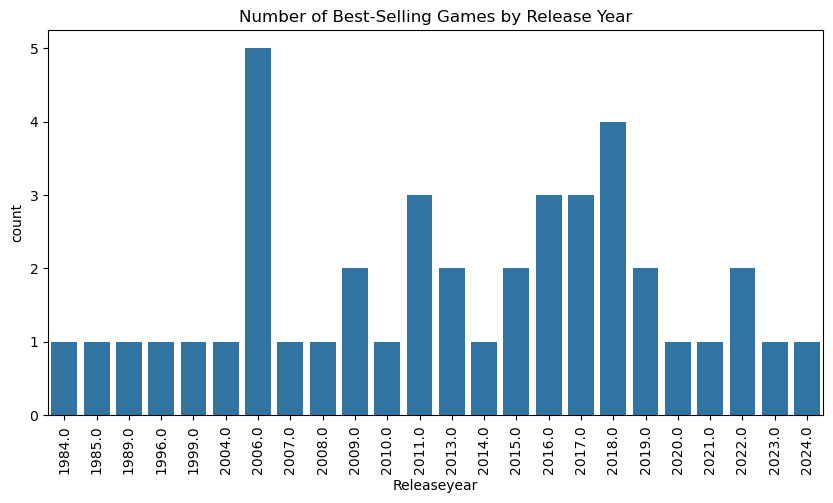

In [15]:
plt.figure(figsize=(10,5))
sns.countplot(data=df,x="Releaseyear")
plt.xticks(rotation=90)
plt.title("Number of Best-Selling Games by Release Year")
plt.show()

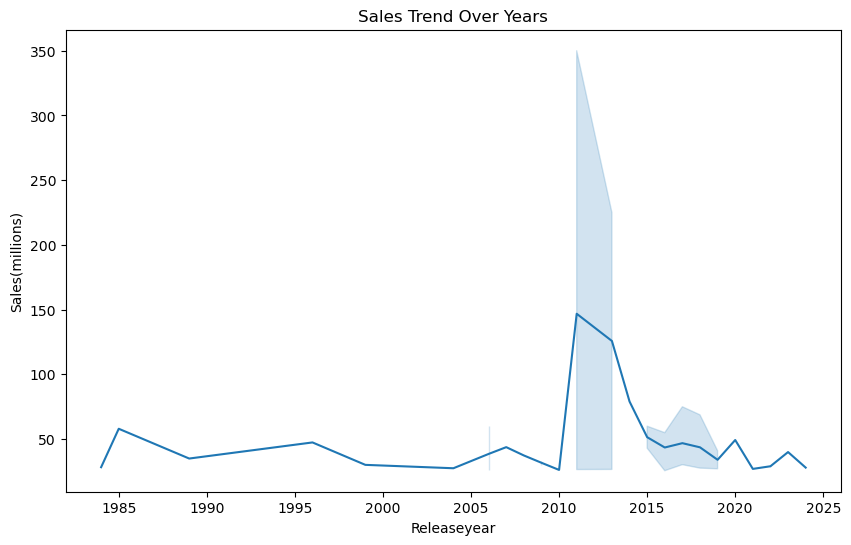

In [17]:
plt.figure(figsize=(10,6))
sns.lineplot(data=df.sort_values("Releaseyear"),x="Releaseyear",y="Sales(millions)")
plt.title("Sales Trend Over Years")
plt.show()

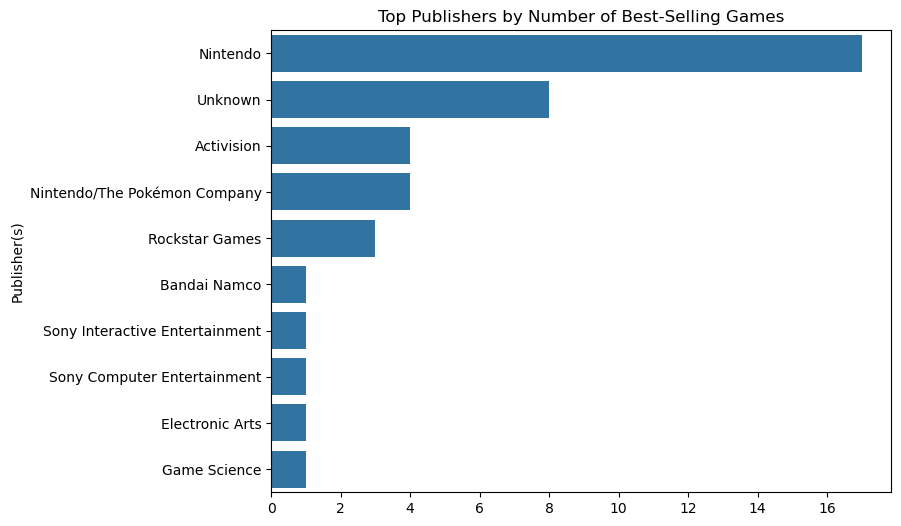

In [19]:
top_publishers = df["Publisher(s)"].value_counts().head(10)
plt.figure(figsize=(8,6))
sns.barplot(y=top_publishers.index, x=top_publishers.values)
plt.title("Top Publishers by Number of Best-Selling Games")
plt.show()

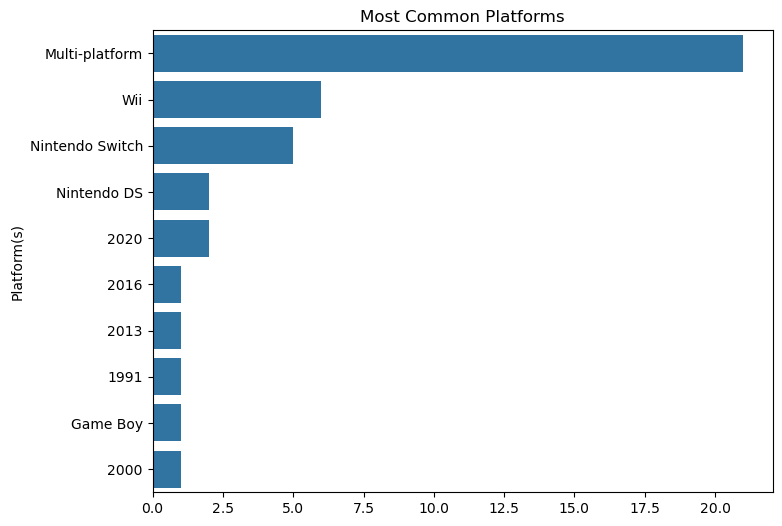

In [20]:
top_platforms = df["Platform(s)"].value_counts().head(10)
plt.figure(figsize=(8,6))
sns.barplot(y=top_platforms.index, x=top_platforms.values)
plt.title("Most Common Platforms")
plt.show()

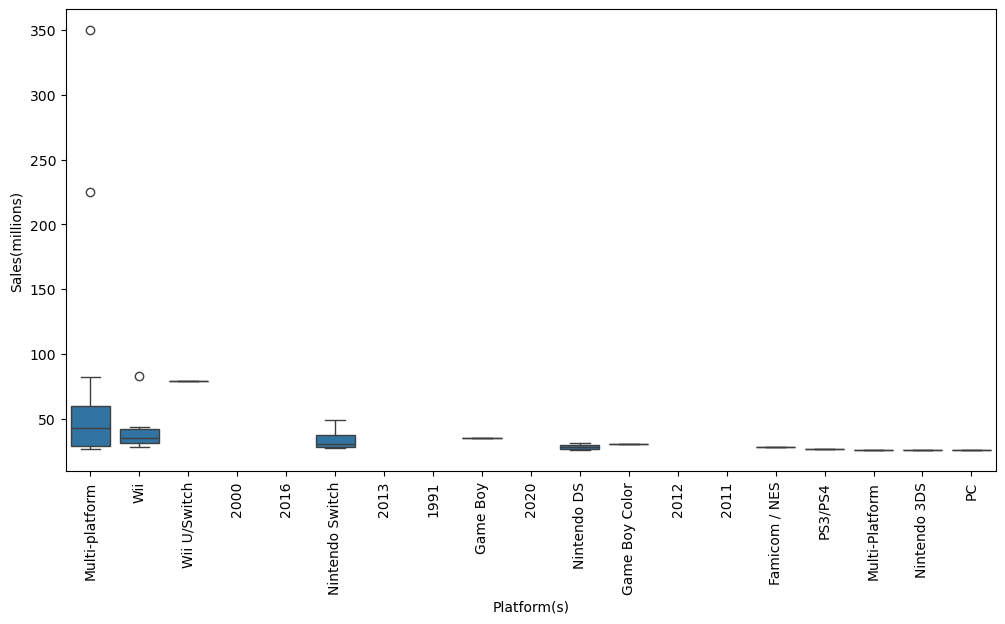

In [21]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df, x="Platform(s)", y="Sales(millions)")
plt.xticks(rotation=90)
plt.show()